# Pair comparison (uncoupled vs concerted)

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
from hdx_env import (UncoupledResidues, ConcertedSwitching,
                     COLORS, LABELS)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
N      = 8
P      = tuple(range(N))
k_int  = np.ones(N)

kop = 0.001
kcl = kop * 100

# uncoupled residues (slow opening/closing, π_op = 0.01)
k_op_i = kop * np.ones(N)
k_cl_i = kcl * np.ones(N)

# Concerted switch with the same equilibrium open fraction
k_op_q = kop
k_cl_q = kcl

t           = np.logspace(-3, 7, 1000)
t_snapshots = np.array([10, 100, 1000, 10000])

ind  = UncoupledResidues(k_op_i, k_cl_i, k_int)
conc = ConcertedSwitching(k_op_q, k_cl_q, k_int)
print(f'N={N}, k_op={k_op_q:g}, k_cl={k_cl_q:g}')

N=8, k_op=0.001, k_cl=0.1


In [3]:
kvals  = np.arange(N + 1)

def moments(ud):
    m1 = (ud * kvals).sum(axis=1)
    return m1, (ud * kvals**2).sum(axis=1) - m1**2

ud_i_t = ind .uptake_distribution(P, t)
ud_c_t = conc.uptake_distribution(P, t)
m_i, v_i = moments(ud_i_t)
m_c, v_c = moments(ud_c_t)

ud_i_s = ind .uptake_distribution(P, t_snapshots)
ud_c_s = conc.uptake_distribution(P, t_snapshots)
print('uptake distributions computed at t =', t_snapshots)

uptake distributions computed at t = [   10   100  1000 10000]


## 3. Single figure — FIG 2 layout

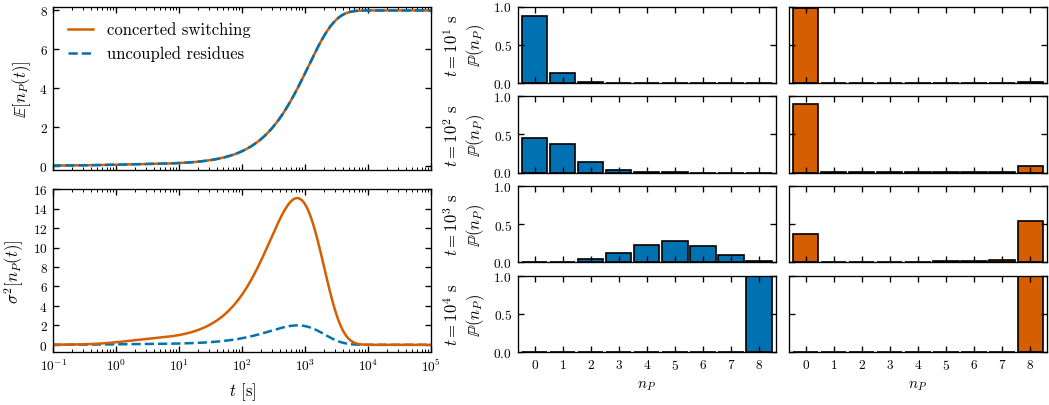

In [4]:
col_ind  = COLORS['uncoupled']
col_conc = COLORS['concerted']
Ns       = len(t_snapshots)

fig = plt.figure(figsize=(9,3.6))

# Two outer columns: one for the stacked time courses, one for the two
# envelope columns side-by-side. Using two GridSpecs (left + right) with
# absolutely positioned bounds lets us pull the envelope block in close to
# the time-course block.
gs_L = fig.add_gridspec(2, 1, hspace=0.12,
                        left=0.07, right=0.42, top=0.93, bottom=0.13)
gs_R = fig.add_gridspec(Ns, 2,  hspace=0.18, wspace=0.05,
                        left=0.50, right=0.99, top=0.93, bottom=0.13)

# ===================== LEFT: centroid + variance =====================
ax_m = fig.add_subplot(gs_L[0, 0])
ax_v = fig.add_subplot(gs_L[1, 0], sharex=ax_m)

ax_m.semilogx(t, m_c, color=col_conc, linestyle='-',  lw=1.5,
              label=LABELS['concerted'])
ax_m.semilogx(t, m_i, color=col_ind,  linestyle='--', lw=1.5,
              label=LABELS['uncoupled'])
ax_m.set_ylabel(r'$\mathbb{E}[n_P(t)]$', fontsize=10)
ax_m.set_xlim(10**-1,10**5)
ax_m.set_ylim(-0.2, N + 0.2)
ax_m.legend(loc='upper left', handlelength=1.5, fontsize=10, frameon=False)
plt.setp(ax_m.get_xticklabels(), visible=False)

ax_v.semilogx(t, v_i, color=col_ind,  lw=1.5, linestyle='--')
ax_v.semilogx(t, v_c, color=col_conc, lw=1.5)
ax_v.set_xlabel(r'$t$ [s]', fontsize=10)
ax_v.set_ylabel(r'$\sigma^2[n_P(t)]$', fontsize=10)
ax_v.set_yticks(np.arange(0,N*2+2,2))

# ============ RIGHT: envelope columns (ind | conc) ====================
xticks = np.arange(0, N + 1, 1)
for ti, tsnap in enumerate(t_snapshots):
    ax_i = fig.add_subplot(gs_R[ti, 0])
    ax_c = fig.add_subplot(gs_R[ti, 1], sharey=ax_i)

    ax_i.bar(kvals, ud_i_s[ti], width=0.9,
             color=col_ind,  edgecolor='black', lw=1)
    ax_c.bar(kvals, ud_c_s[ti], width=0.9,
             color=col_conc, edgecolor='black', lw=1)

    for axe in (ax_i, ax_c):
        axe.set_xticks(xticks)
        axe.set_xlim(-0.6, N + 0.6)
        axe.set_ylim(0, 1.0)
        if ti != Ns - 1:
            plt.setp(axe.get_xticklabels(), visible=False)
        else:
            axe.set_xlabel(r'$n_P$')

    ax_i.set_ylabel(rf'$t=10^{{{np.log10(tsnap):g}}}$ s' + '\n' + r'$\mathbb{P}(n_P)$',
                    fontsize=10)
    plt.setp(ax_c.get_yticklabels(), visible=False)

fig.savefig(os.path.join(PLOTS_DIR, 'fig_comparison_envelope_centroid_variance.pdf'),
            bbox_inches='tight')
plt.show()
